# Boundary Value Problems with pounce

`pounce` ships a `scipy.integrate.solve_bvp`-compatible boundary value problem solver built on
4th-order Hermite–Simpson collocation, plus **differentiable** (JAX / PyTorch) and
**constrained / optimal-control** variants that SciPy has no equivalent for.

This notebook walks through every feature:
1. Drop-in `solve_bvp` and accuracy vs SciPy
2. Solver backends: `method="newton"` (fast, FERAL sparse LU) vs `method="ipm"`
3. Adaptive mesh refinement (matches SciPy)
4. Differentiable solves (JAX): gradients, Jacobians, second order
5. PyTorch frontend
6. Constrained / optimal-control BVPs (pounce-unique)
7. Speed & scaling vs SciPy


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp as scipy_solve_bvp
import pounce
print('pounce', pounce.__version__)


pounce 0.9.0


## 1. Drop-in `solve_bvp`

Same signature as SciPy: `fun(x, y[, p])` returns the `(n, m)` RHS, `bc(ya, yb[, p])` the boundary residuals.
Classic test: `y'' = -|y|`, `y(0)=0`, `y(4)=-2`.


pounce success: True  niter: 5
max |pounce - scipy| over the domain: 1.1102230246251565e-15
collocation rms (pounce): 0.0005576477302220051


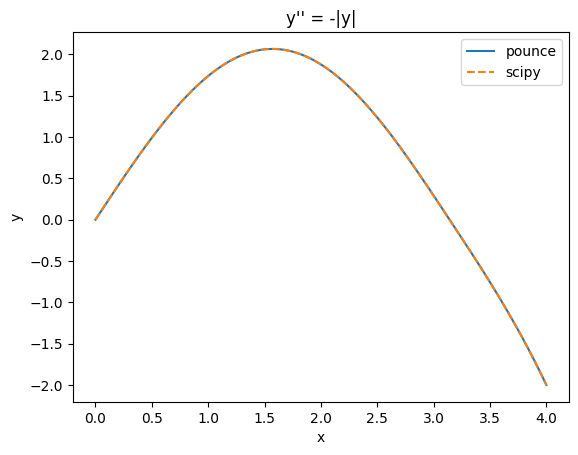

In [2]:
def fun(x, y):
    return np.vstack((y[1], -np.abs(y[0])))
def bc(ya, yb):
    return np.array([ya[0], yb[0] + 2.0])

x = np.linspace(0, 4, 41)
y0 = np.zeros((2, x.size)); y0[0] = 1.0

res = pounce.solve_bvp(fun, bc, x, y0)
ref = scipy_solve_bvp(fun, bc, x, y0)
print('pounce success:', res.success, ' niter:', res.niter)
xt = np.linspace(0, 4, 200)
print('max |pounce - scipy| over the domain:', np.max(np.abs(res.sol(xt)[0] - ref.sol(xt)[0])))
print('collocation rms (pounce):', res.rms_residuals.max())

plt.plot(xt, res.sol(xt)[0], label='pounce'); plt.plot(xt, ref.sol(xt)[0], '--', label='scipy')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.title("y'' = -|y|"); plt.show()


The result bunch mirrors SciPy: `sol` (a callable cubic-Hermite interpolant), `x`, `y`, `yp`, `p`,
`rms_residuals`, `niter`, `status`, `message`, `success`.

**Unknown parameters** work the same way — pass `p=[...]` and `fun(x, y, p)` / `bc(ya, yb, p)`.
Sturm–Liouville eigenvalue: `y'' + k² y = 0`, `y(0)=y(1)=0`, `y'(0)=k` recovers `k = π`.


In [3]:
def fun_e(x, y, p):
    return np.vstack((y[1], -p[0]**2 * y[0]))
def bc_e(ya, yb, p):
    return np.array([ya[0], yb[0], ya[1] - p[0]])

xe = np.linspace(0, 1, 31); ye = np.zeros((2, xe.size))
ye[0] = np.sin(np.pi*xe); ye[1] = np.pi*np.cos(np.pi*xe)
r = pounce.solve_bvp(fun_e, bc_e, xe, ye, p=[3.0], tol=1e-8)
print('recovered eigenvalue p* =', r.p[0], '  (pi =', np.pi, ')')


recovered eigenvalue p* = 3.141592653610359   (pi = 3.141592653589793 )


## 2. Solver backends: `method`

- `method="newton"` (default): damped Newton on the `N×N` collocation system, factored with
  FERAL's unsymmetric sparse LU. Same algorithm as SciPy; this is the fast path.
- `method="ipm"`: pose the collocation system as a pounce feasibility NLP and solve with the
  interior-point method. Basis for the constrained solver in §6.

Both give the same solution.


In [4]:
def fun_b(x, y):
    return np.vstack((y[1], -np.exp(y[0])))   # Bratu
def bc_b(ya, yb):
    return np.array([ya[0], yb[0]])
xb = np.linspace(0, 1, 51); yb0 = np.zeros((2, xb.size))
rn = pounce.solve_bvp(fun_b, bc_b, xb, yb0, method='newton', tol=1e-8, adaptive=False)
ri = pounce.solve_bvp(fun_b, bc_b, xb, yb0, method='ipm', tol=1e-8, adaptive=False)
print('newton vs ipm max |Δy|:', np.max(np.abs(rn.y - ri.y)))


newton vs ipm max |Δy|: 1.4016610094813586e-10


## 3. Adaptive mesh refinement

By default the mesh is **adaptive** (like SciPy), refining until the residual is under `tol`. Pass `adaptive=False` to solve a fixed mesh as-is. The refinement
(driven by `tol` / `max_nodes`). It's a faithful port of SciPy's Lobatto residual estimator and
refinement rule, so it reproduces SciPy's mesh sequence node-for-node.


In [5]:
x5 = np.linspace(0, 1, 5); y5 = np.zeros((2, 5))
ra = pounce.solve_bvp(fun_b, bc_b, x5, y5, tol=1e-6, adaptive=True, max_nodes=2000)
rs = scipy_solve_bvp(fun_b, bc_b, x5, y5, tol=1e-6)
print(f'pounce adaptive: 5 -> {ra.x.size} nodes, rms={ra.rms_residuals.max():.2e}')
print(f'scipy          : 5 -> {rs.x.size} nodes, rms={rs.rms_residuals.max():.2e}')
xt = np.linspace(0,1,300)
print('solution agreement:', np.max(np.abs(ra.sol(xt)[0] - rs.sol(xt)[0])))


pounce adaptive: 5 -> 29 nodes, rms=5.38e-07
scipy          : 5 -> 29 nodes, rms=5.38e-07
solution agreement: 5.551115123125783e-17


Adaptive is **numpy-only**: the differentiable paths below are always fixed-mesh, because a
parameter-dependent mesh would make `y(θ)` nonsmooth and break gradients.


## 4. Differentiable solves (JAX)

`pounce.jax.solve_bvp(fun, bc, x, y, p, theta=...)` returns a solution differentiable w.r.t. `theta`
— any parameter baked into `fun`/`bc` — via the implicit-function theorem on the collocation system.
`fun`/`bc` take a trailing `theta` and are written with `jax.numpy`.


In [6]:
import jax, jax.numpy as jnp
import pounce.jax as pj

# Bratu with the coefficient lambda as the differentiation parameter.
def fun_j(x, y, lam): return jnp.vstack((y[1], -lam * jnp.exp(y[0])))
def bc_j(ya, yb, lam): return jnp.array([ya[0], yb[0]])
xj = jnp.linspace(0, 1, 51); yj = jnp.zeros((2, xj.size))

def y_mid(lam):
    sol = pj.solve_bvp(fun_j, bc_j, xj, yj, theta=lam)
    return sol.y[0, sol.y.shape[1] // 2]

lam = 1.0
g = float(jax.grad(y_mid)(lam))
fd = float((y_mid(lam + 1e-5) - y_mid(lam - 1e-5)) / 2e-5)
print(f'd y(0.5)/d lambda : implicit {g:.10f}  finite-diff {fd:.10f}  rel err {abs(g-fd)/abs(fd):.1e}')


d y(0.5)/d lambda : implicit 0.1592028053  finite-diff 0.1592027712  rel err 2.1e-07


Gradients w.r.t. **boundary values**, the **unknown parameter** `p*`, and the **full solution**
Jacobian `dy/dθ` all work the same way:


In [7]:
# full Jacobian dy(x)/d lambda over the mesh (one factorization via multi-RHS solve_transpose)
J = jax.jacobian(lambda l: pj.solve_bvp(fun_j, bc_j, xj, yj, theta=l).y[0])(1.0)
base = np.asarray(pj.solve_bvp(fun_j, bc_j, xj, yj, theta=1.0).y[0])
fdJ = (np.asarray(pj.solve_bvp(fun_j, bc_j, xj, yj, theta=1.0+1e-5).y[0]) - base) / 1e-5
print('full Jacobian dy/dlambda, max |implicit - FD| over mesh:', np.max(np.abs(np.asarray(J) - fdJ)))


full Jacobian dy/dlambda, max |implicit - FD| over mesh: 1.915470942415176e-07


**Second-order** derivatives through the solve are available with `method="ipm", second_order=True`
(a `custom_jvp` re-applies the implicit function theorem, so JAX recurses):


In [8]:
def y_mid_so(lam):
    sol = pj.solve_bvp(fun_j, bc_j, xj, yj, theta=lam, method='ipm', second_order=True)
    return sol.y[0, sol.y.shape[1] // 2]
h2 = float(jax.grad(jax.grad(y_mid_so))(1.0))
fd2 = float((jax.grad(y_mid_so)(1.0+1e-4) - jax.grad(y_mid_so)(1.0-1e-4)) / 2e-4)
print(f'd2 y(0.5)/d lambda2 : implicit {h2:.6f}  finite-diff {fd2:.6f}')


d2 y(0.5)/d lambda2 : implicit 0.045117  finite-diff 0.045117


## 5. PyTorch frontend

`pounce.torch.solve_bvp` mirrors the JAX path; the returned `y`/`p` are tensors in the autograd graph.


In [9]:
import torch
torch.set_default_dtype(torch.float64)
import pounce.torch as pt
def fun_t(x, y, lam): return torch.vstack((y[1], -lam * torch.exp(y[0])))
def bc_t(ya, yb, lam): return torch.stack([ya[0], yb[0]])
xt_ = torch.linspace(0, 1, 51); yt_ = torch.zeros((2, xt_.shape[0]))
lam_t = torch.tensor(1.0, requires_grad=True)
sol = pt.solve_bvp(fun_t, bc_t, xt_, yt_, theta=lam_t)
sol.y[0, 25].backward()
print('torch d y(0.5)/d lambda =', float(lam_t.grad))


torch d y(0.5)/d lambda = 0.15920280525094732


## 6. Constrained / optimal-control BVPs (pounce-unique)

`pounce.solve_bvp_constrained` adds **state/parameter bounds** and **inequality path constraints**,
optionally minimising an **objective** over an under-determined system (optimal control). SciPy's
`solve_bvp` cannot express any of these.

Example: minimise `∫(y-1)² dx` subject to `y''=0`, `y(0)=0` (slope free → 1 DOF). The unconstrained
optimum is `y(1)=1.5`; adding the bound `y ≤ 1.2` caps it.


unconstrained y(1) = 1.4995  (analytic 1.5)
bounded y<=1.2 y(1) = 1.2000  max y = 1.2000


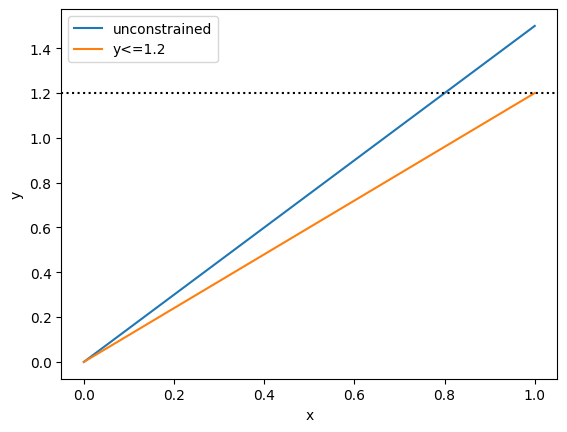

In [10]:
def fun_c(x, y): return np.vstack((y[1], np.zeros_like(y[0])))
def bc_c(ya, yb): return np.array([ya[0]])      # one boundary residual -> 1 DOF
xc = np.linspace(0, 1, 41); yc = np.zeros((2, xc.size)); yc[0] = xc
obj = lambda Y, p: np.trapezoid((Y[0] - 1.0)**2, xc)

r_free = pounce.solve_bvp_constrained(fun_c, bc_c, xc, yc, objective=obj)
r_bnd  = pounce.solve_bvp_constrained(fun_c, bc_c, xc, yc, objective=obj,
                                      y_bounds=([-np.inf,-np.inf],[1.2, np.inf]))
print(f'unconstrained y(1) = {r_free.y[0,-1]:.4f}  (analytic 1.5)')
print(f'bounded y<=1.2 y(1) = {r_bnd.y[0,-1]:.4f}  max y = {r_bnd.y[0].max():.4f}')
plt.plot(xc, r_free.y[0], label='unconstrained'); plt.plot(xc, r_bnd.y[0], label='y<=1.2')
plt.axhline(1.2, ls=':', c='k'); plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()


## 7. Speed & scaling vs SciPy

Both solvers use the same 4th-order collocation and a sparse banded factorization, so **both scale
linearly in the number of mesh nodes**. At equal fixed mesh they are within ~1.5× either way
(pounce a touch faster on cheap 1–2 iteration problems; SciPy a touch faster on large multi-iteration
nonlinear problems). The real pounce win is the *workflow*: solving once on a known mesh (avoiding
SciPy's adaptive resolve cycles), plus differentiability and constraints SciPy lacks.


In [11]:
import time
def t(f, r=5):
    f(); t0=time.perf_counter()
    for _ in range(r): f()
    return 1e3*(time.perf_counter()-t0)/r
print(f"{'nodes':>6} | {'scipy ms':>9} {'pounce ms':>10} {'ratio':>6}")
for m in (51, 201, 801, 3201):
    xm = np.linspace(0, 1, m); ym = np.zeros((2, m))
    ts = t(lambda: scipy_solve_bvp(fun_b, bc_b, xm, ym, tol=1e-6, max_nodes=m))
    tp = t(lambda: pounce.solve_bvp(fun_b, bc_b, xm, ym, tol=1e-6, adaptive=False))
    print(f'{m:>6} | {ts:>9.2f} {tp:>10.2f} {tp/ts:>5.2f}x')


 nodes |  scipy ms  pounce ms  ratio
    51 |      0.40       0.30  0.74x
   201 |      0.50       0.54  1.07x
   801 |      1.02       1.39  1.36x
  3201 |      2.87       4.78  1.67x


### When to use which

| Use case | Best choice |
| --- | --- |
| Plain BVP, unknown good mesh, want robustness | SciPy (or pounce `adaptive=True`) |
| Plain BVP, known/reused mesh | pounce `method='newton'` |
| Need gradients / Jacobians of the solution | **pounce.jax / pounce.torch** (SciPy can't) |
| Bounds / path constraints / optimal control | **pounce.solve_bvp_constrained** (SciPy can't) |
